In [1]:
import numpy as np
import mne
import os.path as op
import matplotlib.pyplot as plt 
import pandas as pd
import matplotlib.lines as mlines
import seaborn as sns
from fooof import FOOOF
from fooof import FOOOFGroup
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.multitest import multipletests
import pingouin as pg

path = '/users/mgarson.stu/.anaconda/VML'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')

adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']

C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_22508\2057971175.py:8: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
#Short Script to play with when playing with data 

#Read in Data for main figure 
g_el_cerebellum_normalized_psds = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_rl_cerebellum_normalized_psds = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds.npy'), allow_pickle=True)
g_el_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'el_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
g_ll_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'll_cerebellum_normalized_psds_c.npy'), allow_pickle=True)
g_rl_cerebellum_normalized_psds_c = np.load(op.join('psd_data', 'rl_cerebellum_normalized_psds_c.npy'), allow_pickle=True)

# Load Stds and significant frequencies
g_std_el_c = np.load(op.join('psd_data', 'std_el_c.npy'), allow_pickle=True)
g_std_ll_c = np.load(op.join('psd_data', 'std_ll_c.npy'), allow_pickle=True)
g_std_rl_c = np.load(op.join('psd_data', 'std_rl_c.npy'), allow_pickle=True)
g_std_el_c_c = np.load(op.join('psd_data', 'std_el_c_c.npy'), allow_pickle=True)
g_std_ll_c_c = np.load(op.join('psd_data', 'std_ll_c_c.npy'), allow_pickle=True)
g_std_rl_c_c = np.load(op.join('psd_data', 'std_rl_c_c.npy'), allow_pickle=True)

g_sig_freqs_cereb_age = np.load(op.join('psd_data', 'sig_freqs_cereb_age.npy'), allow_pickle=True)
g_sig_freqs_cereb_cond = np.load(op.join('psd_data', 'sig_freqs_cereb_cond.npy'), allow_pickle=True)
g_sig_freqs_cereb_int = np.load(op.join('psd_data', 'sig_freqs_cereb_int.npy'), allow_pickle=True)

g_el_motor_normalized_psds = np.load(op.join('psd_data', 'el_motor_normalized_psds.npy'), allow_pickle=True)
g_ll_motor_normalized_psds = np.load(op.join('psd_data', 'll_motor_normalized_psds.npy'), allow_pickle=True)
g_rl_motor_normalized_psds = np.load(op.join('psd_data', 'rl_motor_normalized_psds.npy'), allow_pickle=True)
g_el_motor_normalized_psds_c = np.load(op.join('psd_data', 'el_motor_normalized_psds_c.npy'), allow_pickle=True)
g_ll_motor_normalized_psds_c = np.load(op.join('psd_data', 'll_omtor_normalized_psds_c.npy'), allow_pickle=True)  # Fixed "ll_omtor" typo
g_rl_motor_normalized_psds_c = np.load(op.join('psd_data', 'rl_motor_normalized_psds_c.npy'), allow_pickle=True)

g_el_m_std = np.load(op.join('psd_data', 'el_m_std.npy'), allow_pickle=True)
g_ll_m_std = np.load(op.join('psd_data', 'll_m_std.npy'), allow_pickle=True)
g_rl_m_std = np.load(op.join('psd_data', 'rl_m_std.npy'), allow_pickle=True)
g_el_m_c_std = np.load(op.join('psd_data', 'el_m_std_c.npy'), allow_pickle=True)
g_ll_m_c_std = np.load(op.join('psd_data', 'll_m_std_c.npy'), allow_pickle=True)
g_rl_m_c_std = np.load(op.join('psd_data', 'rl_m_std_c.npy'), allow_pickle=True)

g_sig_freqs_m_age = np.load(op.join('psd_data', 'sig_freqs_m_age.npy'), allow_pickle=True)
g_sig_freqs_m_cond = np.load(op.join('psd_data', 'sig_freqs_m_cond.npy'), allow_pickle=True)
g_sig_freqs_m_int = np.load(op.join('psd_data', 'sig_freqs_m_int.npy'), allow_pickle=True)


In [26]:
a = np.array([[2,2,3], [4,5,6]])
b = np.array([[1,2,3], [6,5,4]])
print(a - b) 

[[ 1  0  0]
 [-2  0  2]]


In [ ]:
#RE-run ANOVA for new significant age effects: 
cerebellum_foofed_spectra_adults_el = []
cerebellum_foofed_spectra_children_el = []
cerebellum_foofed_spectra_adults_ll = []
cerebellum_foofed_spectra_children_ll = []

motor_foofed_spectra_adults_el = []
motor_foofed_spectra_children_el = []
motor_foofed_spectra_adults_ll = []
motor_foofed_spectra_children_ll = []

freqs = np.linspace(1,90,90)
freq_range = [1,90]

for i in range(len(adult_subs)):
    #Read in and smooth the psds for adults
    el = g_el_cerebellum_normalized_psds[i]
    ll = g_ll_cerebellum_normalized_psds[i]

    el_m = g_el_motor_normalized_psds[i]
    ll_m = g_ll_motor_normalized_psds[i]

    fm1 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm2 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm3 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm4 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)

    fm1.fit(freqs, el, freq_range)
    fm2.fit(freqs, ll, freq_range)
    fm3.fit(freqs, el_m, freq_range)
    fm4.fit(freqs, ll_m, freq_range)

    cerebellum_foofed_spectra_adults_el.append(fm1.fooofed_spectrum_)
    cerebellum_foofed_spectra_adults_ll.append(fm2.fooofed_spectrum_)
    motor_foofed_spectra_adults_el.append(fm3.fooofed_spectrum_)
    motor_foofed_spectra_adults_ll.append(fm4.fooofed_spectrum_)


for i in range(len(child_subs)): 
    el_c = g_el_cerebellum_normalized_psds_c[i]
    ll_c = g_ll_cerebellum_normalized_psds_c[i]
    m_el_c = g_el_motor_normalized_psds_c[i]
    m_ll_c = g_ll_motor_normalized_psds_c[i]

    fm3 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm4 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm1 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
    fm2 = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)

    fm1.fit(freqs, m_el_c, freq_range)
    fm2.fit(freqs, m_ll_c, freq_range)
    fm3.fit(freqs, el_c, freq_range)
    fm4.fit(freqs, ll_c, freq_range)

    motor_foofed_spectra_children_el.append(fm1.fooofed_spectrum_)
    motor_foofed_spectra_children_ll.append(fm2.fooofed_spectrum_)
    cerebellum_foofed_spectra_children_el.append(fm3.fooofed_spectrum_)
    cerebellum_foofed_spectra_children_ll.append(fm4.fooofed_spectrum_)

print(np.shape(motor_foofed_spectra_adults_el))
print(np.shape(cerebellum_foofed_spectra_children_el))
#plt.plot(freqs, motor_foofed_spectra_adults_el[1])

#Now that we have arrays of power values for each condition and age, we can run anova sepperately for the motor/cerebellar regions


(12, 90)
(11, 90)


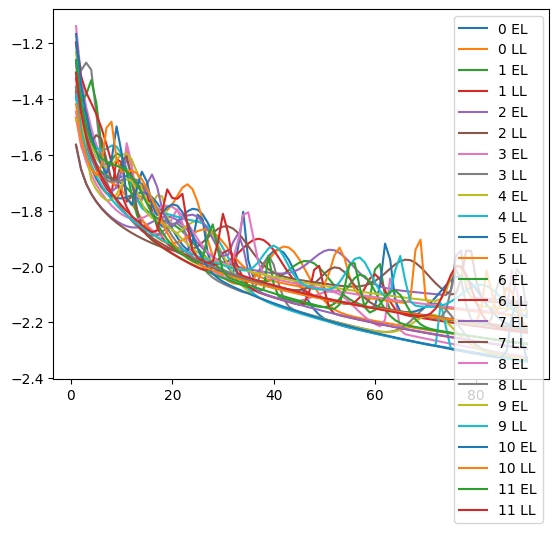

In [69]:
for i in range(len(motor_foofed_spectra_adults_el)): 
    plt.plot(freqs, motor_foofed_spectra_adults_el[i], label=f'{i} EL')
    plt.plot(freqs, motor_foofed_spectra_adults_ll[i], label=f'{i} LL')
    plt.legend()

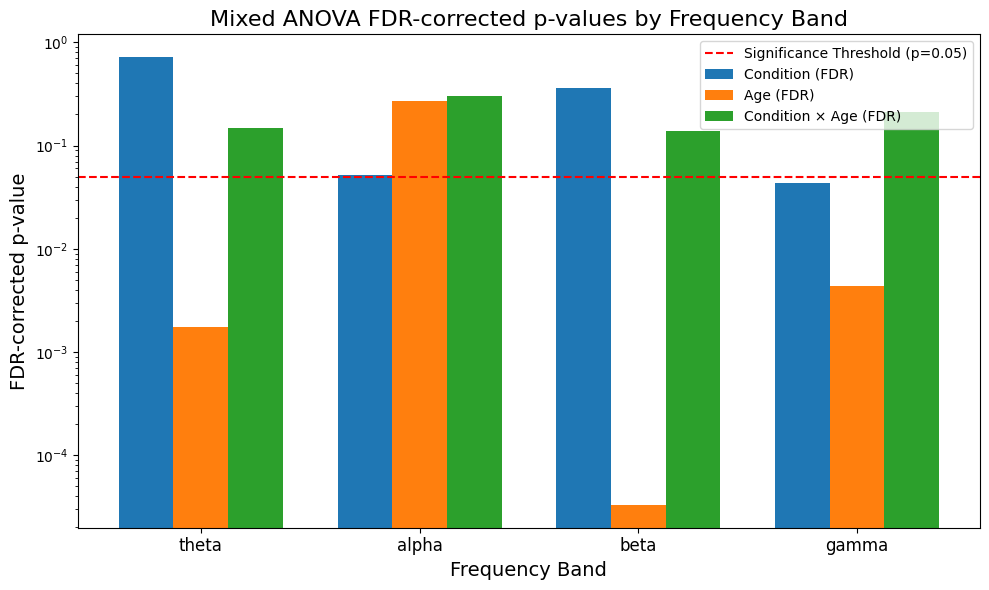

In [ ]:
#Better Code for Running ANOVA on the foofed spectra 

# Define frequency bands
bands = {
    'theta': (4, 7),
    'alpha': (8, 12),
    'beta': (13, 30),
    'gamma': (31, 50)  # adjust if needed
}

# Create participant labels
child_ids = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']
adult_ids = ['011', '012', '013', '014', '018', '019', '021', '022', '025', '026', '030', '031']

# Create master dataframe
master_df = []

for band_name, (f_low, f_high) in bands.items():
    # Get frequency mask
    mask = (freqs >= f_low) & (freqs <= f_high)
    
    # === CHILDREN
    for i, subj in enumerate(child_ids):
        el_band_power = np.mean(motor_foofed_spectra_children_el[i][mask])
        ll_band_power = np.mean(motor_foofed_spectra_children_ll[i][mask])
        
        master_df.append([subj, 'Child', 'EL', band_name, el_band_power])
        master_df.append([subj, 'Child', 'LL', band_name, ll_band_power])

    # === ADULTS
    for i, subj in enumerate(adult_ids):
        el_band_power = np.mean(motor_foofed_spectra_adults_el[i][mask])
        ll_band_power = np.mean(motor_foofed_spectra_adults_ll[i][mask])
        
        master_df.append([subj, 'Adult', 'EL', band_name, el_band_power])
        master_df.append([subj, 'Adult', 'LL', band_name, ll_band_power])

# Create DataFrame
df = pd.DataFrame(master_df, columns=['Subject', 'Age', 'Condition', 'Band', 'Power'])

# Run ANOVA for each band
anova_results = []
for band in df['Band'].unique():
    sub_df = df[df['Band'] == band]
    aov = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=sub_df)
    aov['Band'] = band
    anova_results.append(aov)

# Concatenate results
anova_df = pd.concat(anova_results, ignore_index=True)

# FDR correction per effect
band_list = ['theta', 'alpha', 'beta', 'gamma']

pvals_age_bands = anova_df[anova_df['Source'] == 'Age'].set_index('Band').loc[band_list, 'p-unc'].values
pvals_cond_bands = anova_df[anova_df['Source'] == 'Condition'].set_index('Band').loc[band_list, 'p-unc'].values
pvals_inter_bands = anova_df[anova_df['Source'] == 'Interaction'].set_index('Band').reindex(band_list)['p-unc'].fillna(1.0).values

# Apply FDR
_, age_fdr, _, _ = multipletests(pvals_age_bands, alpha=0.05, method='fdr_bh')
_, cond_fdr, _, _ = multipletests(pvals_cond_bands, alpha=0.05, method='fdr_bh')
_, inter_fdr, _, _ = multipletests(pvals_inter_bands, alpha=0.05, method='fdr_bh')

# Plot as bar chart
x = np.arange(len(band_list))
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, cond_fdr, width=bar_width, label='Condition (FDR)')
plt.bar(x, age_fdr, width=bar_width, label='Age (FDR)')
plt.bar(x + bar_width, inter_fdr, width=bar_width, label='Condition × Age (FDR)')

# Threshold line
plt.axhline(0.05, color='red', linestyle='--', label='Significance Threshold (p=0.05)')

# Labels
plt.xticks(x, band_list, fontsize=12)
plt.yscale('log')
plt.ylabel('FDR-corrected p-value', fontsize=14)
plt.xlabel('Frequency Band', fontsize=14)
plt.title('Mixed ANOVA (MOTOR) FDR-corrected p-values by Frequency Band', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


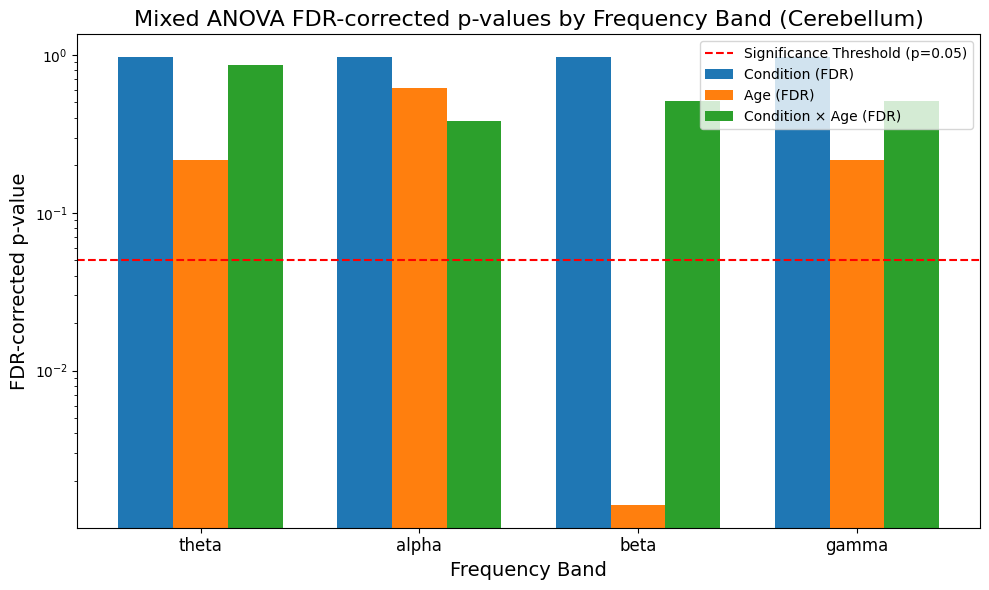

In [78]:
import pandas as pd
import numpy as np
import pingouin as pg
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# === Define frequency bands
bands = {
    'theta': (4, 7),
    'alpha': (8, 12),
    'beta': (13, 30),
    'gamma': (31, 50)
}

# === Participant IDs
child_ids = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']
adult_ids = ['011', '012', '013', '014', '018', '019', '021', '022', '025', '026', '030', '031']

# === Create the long-format DataFrame
master_df = []

for band_name, (f_low, f_high) in bands.items():
    mask = (freqs >= f_low) & (freqs <= f_high)

    # Children
    for i, subj in enumerate(child_ids):
        el_band_power = np.mean(cerebellum_foofed_spectra_children_el[i][mask])
        ll_band_power = np.mean(cerebellum_foofed_spectra_children_ll[i][mask])
        master_df.append([subj, 'Child', 'EL', band_name, el_band_power])
        master_df.append([subj, 'Child', 'LL', band_name, ll_band_power])

    # Adults
    for i, subj in enumerate(adult_ids):
        el_band_power = np.mean(cerebellum_foofed_spectra_adults_el[i][mask])
        ll_band_power = np.mean(cerebellum_foofed_spectra_adults_ll[i][mask])
        master_df.append([subj, 'Adult', 'EL', band_name, el_band_power])
        master_df.append([subj, 'Adult', 'LL', band_name, ll_band_power])

# Create DataFrame
df = pd.DataFrame(master_df, columns=['Subject', 'Age', 'Condition', 'Band', 'Power'])

# Run ANOVA for each band
anova_results = []
for band in df['Band'].unique():
    sub_df = df[df['Band'] == band]
    aov = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=sub_df)
    aov['Band'] = band
    anova_results.append(aov)

# Combine results
anova_df = pd.concat(anova_results, ignore_index=True)

# FDR-correct each effect across bands
band_list = ['theta', 'alpha', 'beta', 'gamma']

pvals_age_bands = anova_df[anova_df['Source'] == 'Age'].set_index('Band').loc[band_list, 'p-unc'].values
pvals_cond_bands = anova_df[anova_df['Source'] == 'Condition'].set_index('Band').loc[band_list, 'p-unc'].values
pvals_inter_bands = anova_df[anova_df['Source'] == 'Interaction'].set_index('Band').reindex(band_list)['p-unc'].fillna(1.0).values

_, age_fdr, _, _ = multipletests(pvals_age_bands, alpha=0.05, method='fdr_bh')
_, cond_fdr, _, _ = multipletests(pvals_cond_bands, alpha=0.05, method='fdr_bh')
_, inter_fdr, _, _ = multipletests(pvals_inter_bands, alpha=0.05, method='fdr_bh')

# === Plot as bar chart
x = np.arange(len(band_list))
bar_width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, cond_fdr, width=bar_width, label='Condition (FDR)', color='tab:blue')
plt.bar(x, age_fdr, width=bar_width, label='Age (FDR)', color='tab:orange')
plt.bar(x + bar_width, inter_fdr, width=bar_width, label='Condition × Age (FDR)', color='tab:green')

# Significance threshold
plt.axhline(0.05, color='red', linestyle='--', label='Significance Threshold (p=0.05)')

# Labels and aesthetics
plt.xticks(x, band_list, fontsize=12)
plt.yscale('log')
plt.ylabel('FDR-corrected p-value', fontsize=14)
plt.xlabel('Frequency Band', fontsize=14)
plt.title('Mixed ANOVA FDR-corrected p-values by Frequency Band (Cerebellum)', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
#ANOVA MOTOR (NO RE-LEARNING)

# Initialize p-value lists
pvals_condition_m = []
pvals_age_m = []
pvals_interaction_m = []

# Loop through all 90 frequencies
for i in range(len(freqs)):

    # Extract condition-specific normalized power
    elc = motor_foofed_spectra_children_el
    llc = motor_foofed_spectra_children_ll
    el = motor_foofed_spectra_adults_el
    ll = motor_foofed_spectra_adults_ll

    # Children
    el_03 = elc[0][i]; ll_03 = llc[0][i]
    el_02 = elc[1][i]; ll_02 = llc[1][i]
    el_04 = elc[2][i]; ll_04 = llc[2][i]
    el_06 = elc[3][i]; ll_06 = llc[3][i]
    el_09 = elc[4][i]; ll_09 = llc[4][i]
    el_010 = elc[5][i]; ll_010 = llc[5][i]
    el_015 = elc[6][i]; ll_015 = llc[6][i]
    el_016 = elc[7][i]; ll_016 = llc[7][i]
    el_027 = elc[8][i]; ll_027 = llc[8][i]
    el_028 = elc[9][i]; ll_028 = llc[9][i]
    el_029 = elc[10][i]; ll_029 = llc[10][i]

    # Adults
    el_011 = el[0][i]; ll_011 = ll[0][i]
    el_012 = el[1][i]; ll_012 = ll[1][i]
    el_013 = el[2][i]; ll_013 = ll[2][i]
    el_014 = el[3][i]; ll_014 = ll[3][i]
    el_018 = el[4][i]; ll_018 = ll[4][i]
    el_019 = el[5][i]; ll_019 = ll[5][i]
    el_021 = el[6][i]; ll_021 = ll[6][i]
    el_022 = el[7][i]; ll_022 = ll[7][i]
    el_025 = el[8][i]; ll_025 = ll[8][i]
    el_026 = el[9][i]; ll_026 = ll[9][i]
    el_030 = el[10][i]; ll_030 = ll[10][i]
    el_031 = el[11][i]; ll_031 = ll[11][i]

    # Create DataFrame with only EL and LL conditions
    data = pd.DataFrame({
        'Subject': ['003', '003', '002', '002', '004', '004', '006', '006', '009', '009', '010', '010',
                    '015', '015', '016', '016', '027', '027', '028', '028', '029', '029',
                    '011', '011', '012', '012', '013', '013', '014', '014', '018', '018',
                    '019', '019', '021', '021', '022', '022', '025', '025', '026', '026',
                    '030', '030', '031', '031'],
        'Age': ['Child'] * 22 + ['Adult'] * 24,
        'Condition': ['EL', 'LL'] * 23,
        'Power': [el_03, ll_03, el_02, ll_02, el_04, ll_04, el_06, ll_06, el_09, ll_09,
                  el_010, ll_010, el_015, ll_015, el_016, ll_016, el_027, ll_027, el_028, ll_028,
                  el_029, ll_029, el_011, ll_011, el_012, ll_012, el_013, ll_013, el_014, ll_014,
                  el_018, ll_018, el_019, ll_019, el_021, ll_021, el_022, ll_022, el_025, ll_025,
                  el_026, ll_026, el_030, ll_030, el_031, ll_031]
    })

    # Run Mixed ANOVA
    anova = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=data)
    cond_pv = anova.loc[anova['Source'] == 'Condition', 'p-unc'].values[0]
    age_pv = anova.loc[anova['Source'] == 'Age', 'p-unc'].values[0]
    interaction_pv = anova.loc[anova['Source'] == 'Interaction', 'p-unc'].values[0]

    # Store p-values
    pvals_condition_m.append(cond_pv)
    pvals_age_m.append(age_pv)
    pvals_interaction_m.append(interaction_pv)

#Correct p-values 
trues_age_m, pvals_age_cor_m, _, _ = multipletests(pvals_age_m, alpha=0.05, method='fdr_bh')
trues_cond_m, pvals_condition_cor_m, _, _ = multipletests(pvals_condition_m, alpha=0.05, method='fdr_bh')
trues_int_m, pvals_interaction_cor_m, _, _ = multipletests(pvals_interaction_m, alpha=0.05, method='fdr_bh')

sig_freqs_m_age = []
sig_freqs_m_cond = []
sig_freqs_m_int = []

age_count_m = 0  
cond_count_m = 0  
int_count_m = 0  

for i in range(len(freqs)):
    if trues_age_m[i]:
        sig_freqs_m_age.append(freqs[i])
        age_count_m += 1
    if trues_cond_m[i]:
        sig_freqs_m_cond.append(freqs[i])
        cond_count_m += 1
    if trues_int_m[i]:
        sig_freqs_m_int.append(freqs[i])
        int_count_m += 1 

print(age_count_m, 'Significant Age differences found at :', sig_freqs_m_age)
print(cond_count_m, 'Significant Age differences found at :', sig_freqs_m_cond)
print(int_count_m, 'Significant Age differences found at :', sig_freqs_m_int)


70 Significant Age differences found at : [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 81.0, 82.0, 90.0]
0 Significant Age differences found at : []
0 Significant Age differences found at : []


In [59]:
#ANOVA CEREBELLUM (NO RE-LEARNING)

# Initialize p-value lists
pvals_condition_c = []
pvals_age_c = []
pvals_interaction_c = []

# Loop through all 90 frequencies
for i in range(len(freqs)):

    # Extract condition-specific normalized power
    elc = cerebellum_foofed_spectra_children_el
    llc = cerebellum_foofed_spectra_children_ll
    el = cerebellum_foofed_spectra_adults_el
    ll = cerebellum_foofed_spectra_adults_ll

    # Children
    el_03 = elc[0][i]; ll_03 = llc[0][i]
    el_02 = elc[1][i]; ll_02 = llc[1][i]
    el_04 = elc[2][i]; ll_04 = llc[2][i]
    el_06 = elc[3][i]; ll_06 = llc[3][i]
    el_09 = elc[4][i]; ll_09 = llc[4][i]
    el_010 = elc[5][i]; ll_010 = llc[5][i]
    el_015 = elc[6][i]; ll_015 = llc[6][i]
    el_016 = elc[7][i]; ll_016 = llc[7][i]
    el_027 = elc[8][i]; ll_027 = llc[8][i]
    el_028 = elc[9][i]; ll_028 = llc[9][i]
    el_029 = elc[10][i]; ll_029 = llc[10][i]

    # Adults
    el_011 = el[0][i]; ll_011 = ll[0][i]
    el_012 = el[1][i]; ll_012 = ll[1][i]
    el_013 = el[2][i]; ll_013 = ll[2][i]
    el_014 = el[3][i]; ll_014 = ll[3][i]
    el_018 = el[4][i]; ll_018 = ll[4][i]
    el_019 = el[5][i]; ll_019 = ll[5][i]
    el_021 = el[6][i]; ll_021 = ll[6][i]
    el_022 = el[7][i]; ll_022 = ll[7][i]
    el_025 = el[8][i]; ll_025 = ll[8][i]
    el_026 = el[9][i]; ll_026 = ll[9][i]
    el_030 = el[10][i]; ll_030 = ll[10][i]
    el_031 = el[11][i]; ll_031 = ll[11][i]

    # Create DataFrame with only EL and LL conditions
    data = pd.DataFrame({
        'Subject': ['003', '003', '002', '002', '004', '004', '006', '006', '009', '009', '010', '010',
                    '015', '015', '016', '016', '027', '027', '028', '028', '029', '029',
                    '011', '011', '012', '012', '013', '013', '014', '014', '018', '018',
                    '019', '019', '021', '021', '022', '022', '025', '025', '026', '026',
                    '030', '030', '031', '031'],
        'Age': ['Child'] * 22 + ['Adult'] * 24,
        'Condition': ['EL', 'LL'] * 23,
        'Power': [el_03, ll_03, el_02, ll_02, el_04, ll_04, el_06, ll_06, el_09, ll_09,
                  el_010, ll_010, el_015, ll_015, el_016, ll_016, el_027, ll_027, el_028, ll_028,
                  el_029, ll_029, el_011, ll_011, el_012, ll_012, el_013, ll_013, el_014, ll_014,
                  el_018, ll_018, el_019, ll_019, el_021, ll_021, el_022, ll_022, el_025, ll_025,
                  el_026, ll_026, el_030, ll_030, el_031, ll_031]
    })

    # Run Mixed ANOVA
    anova = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=data)
    cond_pv = anova.loc[anova['Source'] == 'Condition', 'p-unc'].values[0]
    age_pv = anova.loc[anova['Source'] == 'Age', 'p-unc'].values[0]
    interaction_pv = anova.loc[anova['Source'] == 'Interaction', 'p-unc'].values[0]

    # Store p-values
    pvals_condition_c.append(cond_pv)
    pvals_age_c.append(age_pv)
    pvals_interaction_c.append(interaction_pv)

#Correct p-values 
trues_age_c, pvals_age_cor_c, _, _ = multipletests(pvals_age_c, alpha=0.05, method='fdr_bh')
trues_cond_c, pvals_condition_cor_c, _, _ = multipletests(pvals_condition_c, alpha=0.05, method='fdr_bh')
trues_int_c, pvals_interaction_cor_c, _, _ = multipletests(pvals_interaction_c, alpha=0.05, method='fdr_bh')

sig_freqs_c_age = []
sig_freqs_c_cond = []
sig_freqs_c_int = []

age_count_c = 0  
cond_count_c = 0  
int_count_c = 0  

for i in range(len(freqs)):
    if trues_age_c[i]:
        sig_freqs_c_age.append(freqs[i])
        age_count_c += 1
    if trues_cond_c[i]:
        sig_freqs_c_cond.append(freqs[i])
        cond_count_c += 1
    if trues_int_c[i]:
        sig_freqs_c_int.append(freqs[i])
        int_count_c += 1 

print(age_count_c, 'Significant Age differences found at :', sig_freqs_c_age)
print(cond_count_c, 'Significant Age differences found at :', sig_freqs_c_cond)
print(int_count_c, 'Significant Age differences found at :', sig_freqs_c_int)


6 Significant Age differences found at : [17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
0 Significant Age differences found at : []
0 Significant Age differences found at : []


In [60]:
methods = ['bonferroni', 'sidak', 'holm-sidak', 'holm', 'simes-hochberg', 'hommel', 'fdr_bh', 'fdr_by', 'fdr_tsbh', 'fdr_tsbky']

#Determine best correction method 
for method in methods: 
    trues, corrected, _, _ = multipletests(pvals_age_m, alpha=0.01, method=method)
    counter = 0
    for i in range(len(trues)):
        if trues[i]:
            #print(i)
            counter += 1

    print(counter, 'significant frequencies with age for the', method, 'method')

print("CEREBELLUM NOW")

#Determine best correction method 
for method in methods: 
    trues, corrected, _, _ = multipletests(pvals_age_c, alpha=0.05, method=method)
    counter = 0
    for i in range(len(trues)):
        if trues[i]:
            #print(i)
            counter += 1

    print(counter, 'significant frequencies with age for the', method, 'method')

7 significant frequencies with age for the bonferroni method
7 significant frequencies with age for the sidak method
8 significant frequencies with age for the holm-sidak method
7 significant frequencies with age for the holm method
7 significant frequencies with age for the simes-hochberg method
8 significant frequencies with age for the hommel method
23 significant frequencies with age for the fdr_bh method
15 significant frequencies with age for the fdr_by method
27 significant frequencies with age for the fdr_tsbh method
27 significant frequencies with age for the fdr_tsbky method
CEREBELLUM NOW
0 significant frequencies with age for the bonferroni method
0 significant frequencies with age for the sidak method
0 significant frequencies with age for the holm-sidak method
0 significant frequencies with age for the holm method
0 significant frequencies with age for the simes-hochberg method
0 significant frequencies with age for the hommel method
6 significant frequencies with age for

In [ ]:
#Playing with stats to try getting more accurate significant frequencies



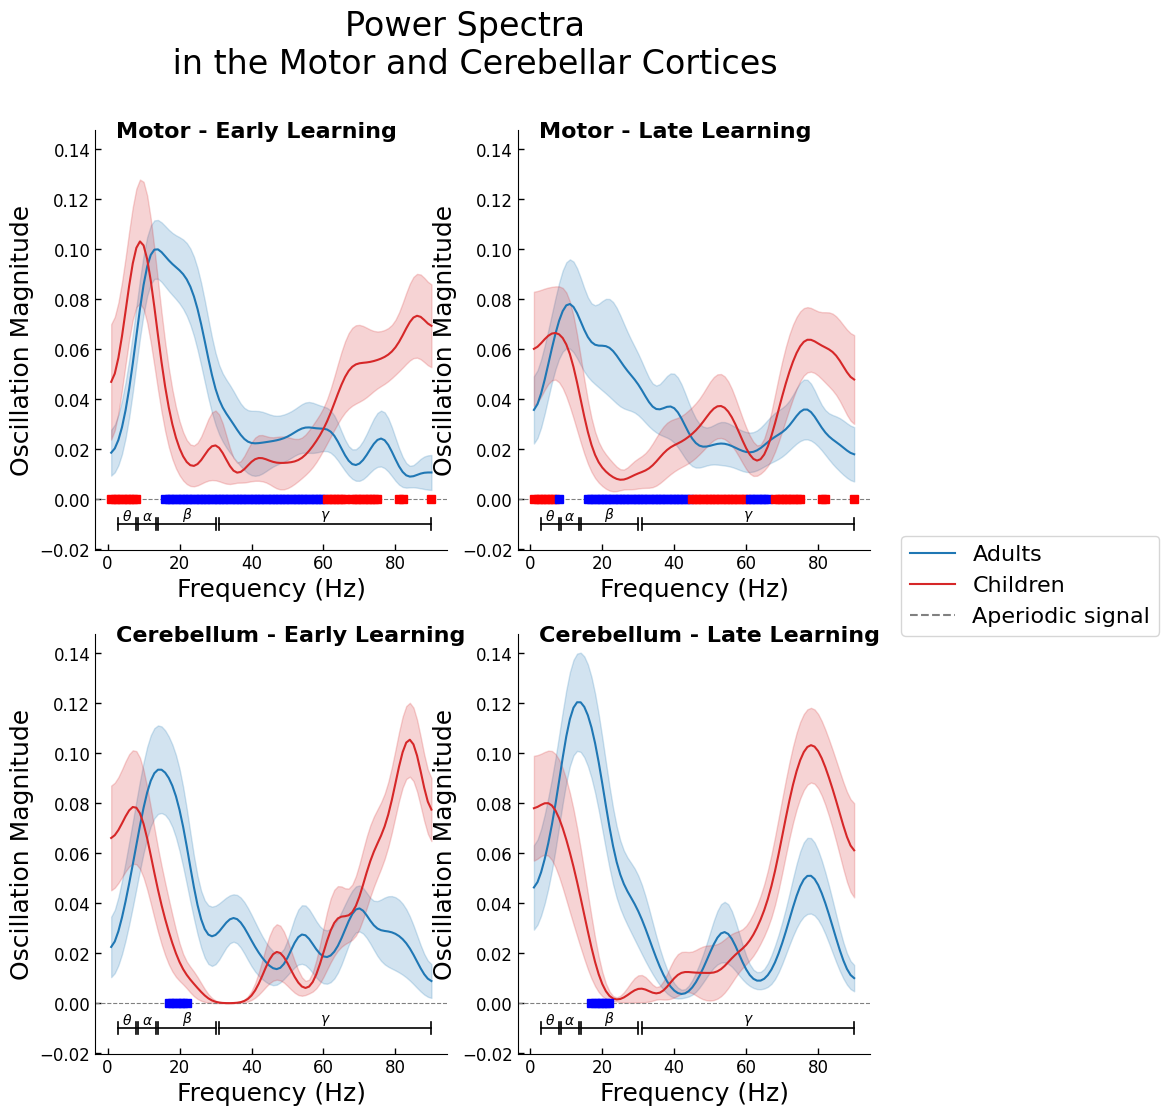

In [77]:
#Define Frequency Parameters
freqs = np.linspace(1,90,90)
freq_range = [1,90]

#For the Smoothing
sigma = 3 

# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
fig.suptitle("Power Spectra \n in the Motor and Cerebellar Cortices", fontsize=24)

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:
        # Dynamically load the right data
        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []

        #For frequency bands 
        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)

        # === Averages
        avg_adult_spectrum = np.mean(np.array(adult_spectra) - np.array(adult_backgrounds), axis=0)
        avg_child_spectrum = np.mean(np.array(child_spectra) - np.array(child_backgrounds), axis=0)

        #Smooth the Spectra 
        adult_smooth = gaussian_filter1d(avg_adult_spectrum, sigma=sigma)
        child_smooth = gaussian_filter1d(avg_child_spectrum, sigma=sigma)

        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # Convert to arrays
        adult_oscillatory = np.array(adult_spectra) - np.array(adult_backgrounds)
        child_oscillatory = np.array(child_spectra) - np.array(child_backgrounds)

        # Apply Gaussian smoothing to each participant’s spectrum
        adult_smooth_all = gaussian_filter1d(adult_oscillatory, sigma=sigma, axis=1)
        child_smooth_all = gaussian_filter1d(child_oscillatory, sigma=sigma, axis=1)

        # Mean spectrum
        adult_smooth = np.mean(adult_smooth_all, axis=0)
        child_smooth = np.mean(child_smooth_all, axis=0)

        # Standard Error of the Mean (SEM)
        adult_sem = np.std(adult_smooth_all, axis=0) / np.sqrt(adult_smooth_all.shape[0])
        child_sem = np.std(child_smooth_all, axis=0) / np.sqrt(child_smooth_all.shape[0])

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # Add baseline line at y = 0
        ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')


        # Plot color-coded squares based on group power difference
        if brain_region == 'motor':
            for freq in sig_freqs_m_age:
                idx = np.where(freqs == freq)[0]
                if len(idx) > 0:
                    idx = idx[0]
                    color = 'blue' if adult_smooth[idx] > child_smooth[idx] else 'red'
                    ax.plot(freq, 0, marker='s', color=color, markersize=6, zorder=5)


        elif brain_region == 'cerebellum':
            for freq in sig_freqs_c_age:
                idx = np.where(freqs == freq)[0]
                if len(idx) > 0:
                    idx = idx[0]
                    color = 'blue' if adult_smooth[idx] > child_smooth[idx] else 'red'
                    ax.plot(freq, 0, marker='s', color=color, markersize=6, zorder=5)


        # === Plot
        ax.plot(freqs, adult_smooth, color='tab:blue', label='Adults')
        ax.plot(freqs, child_smooth, color='tab:red', label='Children')

        # === Shade in SEM 
        ax.fill_between(freqs, adult_smooth - adult_sem, adult_smooth + adult_sem, color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, child_smooth - child_sem, child_smooth + child_sem, color='tab:red', alpha=0.2)

        #Plot the frequency bands 
        band_labels = [r'$\theta$', r'$\alpha$', r'$\beta$', r'$\gamma$']
        band_positions = [(3, 8), (8.5, 13.5), (14, 30), (31, 90)]
        x_offsets = [-1.5, 0, 1.5, 3]
        y_offset = -0.01
        tick_length = 0.0025
        label_height = 0.0003

        # Draw horizontal bars, ticks, and labels for frequency bands
        for (start, end), label in zip(band_positions, band_labels):
            # Horizontal band line
            ax.plot([start, end], [y_offset, y_offset], color='black', linewidth=1.2)

            # Vertical ticks at band edges
            ax.plot([start, start], [y_offset - tick_length, y_offset + tick_length], color='black', linewidth=1.2)
            ax.plot([end, end], [y_offset - tick_length, y_offset + tick_length], color='black', linewidth=1.2)

            # Label above the line
            ax.text((start + end) / 2, y_offset + label_height, label, ha='center', va='bottom', fontsize=10)

        
        #Set Subplot Titles
        ax.text(0.06, 1.02,
        f"{brain_region.capitalize()} - {'Early' if condition == 'g_el' else 'Late'} Learning",
        transform=ax.transAxes,
        fontsize=16,
        weight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax.set_xlabel('Frequency (Hz)', fontsize=18)
        ax.set_ylabel('Oscillation Magnitude', fontsize=18)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        #ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        #ax.set_xticks([0, 20, 40, 60, 80])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')
        #ax.set_xlim(0,20)
        # Define band positions and labels


# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


[0.00806669 0.00493026 0.00364683 0.00218743 0.0016121  0.00171293
 0.00171461 0.00208137 0.00190174 0.0021633  0.0023215  0.00108611
 0.00092102 0.00095551 0.00091283 0.00086482 0.00062058 0.00046821
 0.00055473 0.00059817 0.00048185 0.00039823 0.00054801 0.00040464
 0.00029417 0.00045004 0.00039054 0.00029164 0.00038062 0.00062558
 0.00058221 0.00041953 0.00051175 0.00053153 0.00039293 0.00046794
 0.00038968 0.00054989 0.00071564 0.0005036  0.0007028  0.00066163
 0.00051472 0.00049127 0.00059159 0.0005463  0.0004645  0.00060405
 0.00049697 0.00053696 0.00056338 0.00039411 0.00045703 0.00035872
 0.00036074 0.00040778 0.00036734 0.00044052 0.00044323 0.00035568
 0.00049775 0.00052025 0.00048681 0.00062149 0.00048993 0.00043178
 0.00051646 0.00055506 0.00047466 0.0003881  0.00055937 0.00042636
 0.00039527 0.0004159  0.0004769  0.00048051 0.00046946 0.00046913
 0.0006228  0.00051894 0.00050792 0.00045267 0.000318   0.00038768
 0.00045622 0.00046405 0.00050365 0.00044219 0.00039406 0.0004

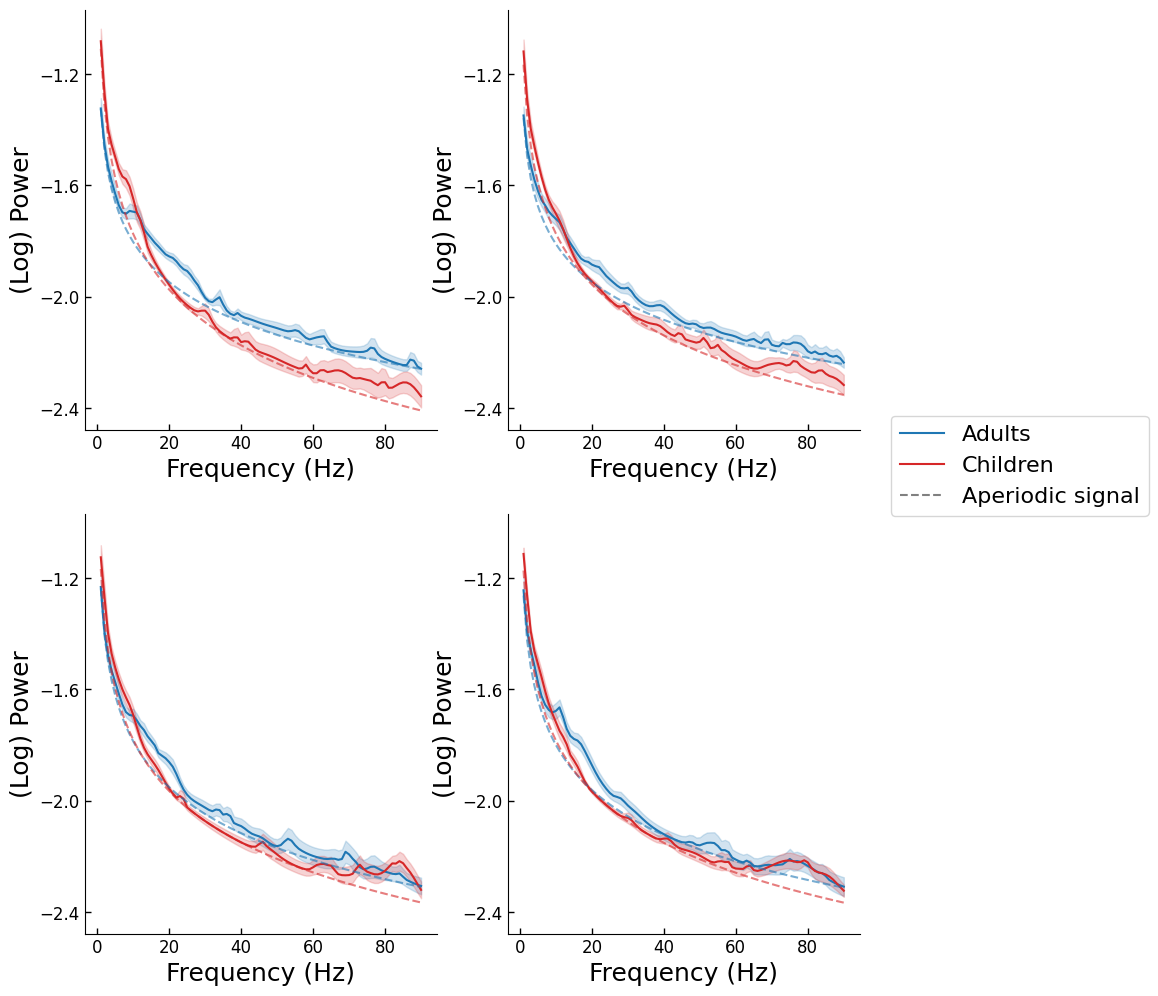

In [20]:
# Create the figure and axes grid *before* the loops
fig, axs = plt.subplots(2, 2, figsize=(10,12), sharex=True, sharey=True)
#fig.suptitle("Power Spectra \n in the Motor and Cerebellar Cortices", fontsize=24)

freqs = np.linspace(1,90,90)
freq_range = [1,90]

# Loop through each condition + region
for condition in ['g_el', 'g_ll']:
    for brain_region in ['motor', 'cerebellum']:
        # Dynamically load the right data
        adult_var_name = f"{condition}_{brain_region}_normalized_psds"
        child_var_name = f"{condition}_{brain_region}_normalized_psds_c"
        adult_data = globals()[adult_var_name]
        child_data = globals()[child_var_name]

        # Prep containers
        child_spectra, adult_spectra = [], [] 
        adult_backgrounds, child_backgrounds = [], []

        log_freqs = np.log10(freqs)
        theta_mask = (freqs >= 4) & (freqs <= 8)
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # === Adults
        for i in range(len(adult_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, adult_data[i], freq_range)
            adult_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            adult_backgrounds.append(background)

        # === Children
        for i in range(len(child_subs)): 
            fm = FOOOF(peak_width_limits=[1.0, 8.0], max_n_peaks=4,
                       min_peak_height=0.1, peak_threshold=2.0, aperiodic_mode='fixed', verbose=False)
            fm.fit(freqs, child_data[i], freq_range)
            child_spectra.append(fm.fooofed_spectrum_)
            slope, offset = fm.aperiodic_params_[1], fm.aperiodic_params_[0]
            background = offset - slope * log_freqs
            child_backgrounds.append(background)

        #Save adult/children FOOFED spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        filename_adult = f'foofed_{condition}_{brain_region}_adult.npy'
        filename_child = f'foofed_{condition}_{brain_region}_child.npy'

        np.save(filename_adult, adult_spectra)
        np.save(filename_child, child_spectra)
        np.save(f'background_{condition}_{brain_region}_adult.npy', np.array(adult_backgrounds))
        np.save(f'background_{condition}_{brain_region}_child.npy', np.array(child_backgrounds))


        # === Averages
        avg_adult_spectrum = np.mean(adult_spectra, axis=0)
        avg_child_spectrum = np.mean(child_spectra, axis=0)
        avg_adult_background = np.mean(adult_backgrounds, axis=0)
        avg_child_background = np.mean(child_backgrounds, axis=0)

        # === Subplot mapping
        subplot_map = {
            ('g_el', 'motor'): (0, 0),
            ('g_ll', 'motor'): (0, 1),
            ('g_el', 'cerebellum'): (1, 0),
            ('g_ll', 'cerebellum'): (1, 1),
        }
        row, col = subplot_map[(condition, brain_region)]
        ax = axs[row][col]

        # === Plot
        ax.plot(freqs, avg_adult_spectrum, color='tab:blue', label='Adults')
        ax.plot(freqs, avg_child_spectrum, color='tab:red', label='Children')
        ax.plot(freqs, avg_adult_background, color='tab:blue', linestyle='--', alpha=0.6)
        ax.plot(freqs, avg_child_background, color='tab:red', linestyle='--', alpha=0.6)
        # ax.fill_between(freqs[theta_mask], avg_child_background[theta_mask], avg_child_spectrum[theta_mask],
        #                 color='tab:red', alpha=0.3)
        # ax.fill_between(freqs[alpha_mask], avg_adult_background[alpha_mask], avg_adult_spectrum[alpha_mask],
        #                 color='tab:blue', alpha=0.3)
        # ax.axvspan(4, 8, color='red', alpha=0.08)
        # ax.axvspan(8, 12, color='blue', alpha=0.08)
        
        #Set Subplot Titles
        # ax.text(0.23, 0.92,
        # f"{brain_region.capitalize()} {'\n Early' if condition == 'g_el' else '\n Late'} Learning",
        # transform=ax.transAxes,
        # fontsize=16,
        # weight='bold',
        # verticalalignment='top',
        # bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        # === Compute SEM from FOOOFed Spectra
        adult_spectra = np.array(adult_spectra)  # shape: [n_subjects, n_freqs]
        child_spectra = np.array(child_spectra)

        sem_adult = np.std(adult_spectra, axis=0, ddof=1) / np.sqrt(adult_spectra.shape[0])
        sem_child = np.std(child_spectra, axis=0, ddof=1) / np.sqrt(child_spectra.shape[0])

        np.save(f'sem_{condition}_{brain_region}_adult.npy', sem_adult)
        np.save(f'sem_{condition}_{brain_region}_child.npy', sem_child)

        # === Error Shading (SEM)
        ax.fill_between(freqs, avg_adult_spectrum - sem_adult, avg_adult_spectrum + sem_adult,
                        color='tab:blue', alpha=0.2)
        ax.fill_between(freqs, avg_child_spectrum - sem_child, avg_child_spectrum + sem_child,
                        color='tab:red', alpha=0.2)

        ax.set_xlabel('Frequency (Hz)', fontsize=18)
        ax.set_ylabel('(Log) Power', fontsize=18)
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=12)  # or 14 if you want bigger
        #ax.tick_params(top=True, right=True, direction='in', length=4, width=1)
        ax.tick_params(bottom=True, left=True, direction='in', length=4, width=1)
        ax.tick_params(labelbottom=True)
        ax.tick_params(labelleft=True)
        ax.set_yticks([-2.4, -2.0, -1.6, -1.2])
        ax.set_xticks([0, 20, 40, 60, 80])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        for spine in ax.spines.values():
            spine.set_color('black')

# Custom aperiodic signal handle
aperiodic_handle = mlines.Line2D([], [], color='gray', linestyle='--', label='Aperiodic signal')

# Collect handles and labels from all subplots
handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Add the custom aperiodic signal
handles.append(aperiodic_handle)
labels.append('Aperiodic signal')

# Remove duplicates (optional)
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center left', bbox_to_anchor=(0.92, 0.5), fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('periodic_aperiodic_psd', dpi=300, bbox_inches='tight')
plt.show()

70 Significant Age differences found at : [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 81.0, 82.0, 90.0]
0 Significant Condition differences found at : []
0 Significant Interaction differences found at : []


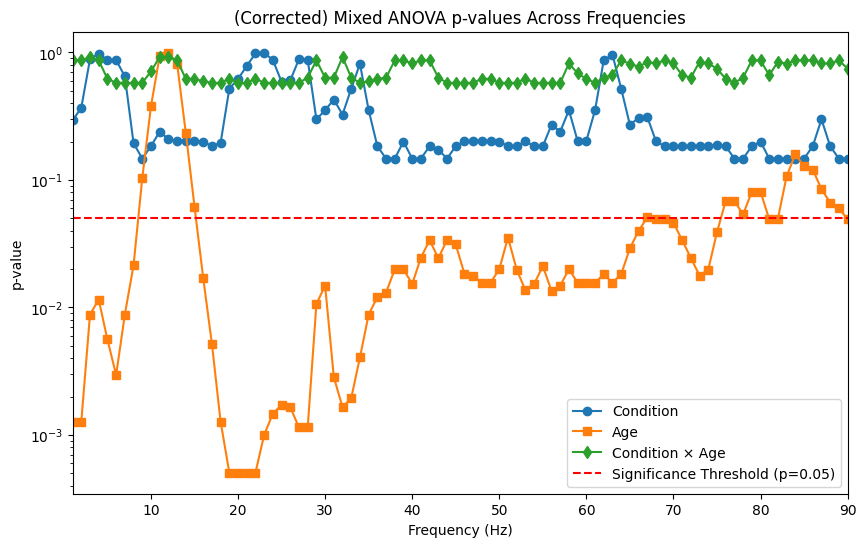

=== AGE Effect: Multiple Comparison Corrections ===
16 significant frequencies with age for the 'bonferroni' method
17 significant frequencies with age for the 'sidak' method
17 significant frequencies with age for the 'holm-sidak' method
17 significant frequencies with age for the 'holm' method
17 significant frequencies with age for the 'simes-hochberg' method
18 significant frequencies with age for the 'hommel' method
70 significant frequencies with age for the 'fdr_bh' method
23 significant frequencies with age for the 'fdr_by' method
85 significant frequencies with age for the 'fdr_tsbh' method
85 significant frequencies with age for the 'fdr_tsbky' method

=== CONDITION Effect: Multiple Comparison Corrections ===
0 significant frequencies with condition for the 'bonferroni' method
0 significant frequencies with condition for the 'sidak' method
0 significant frequencies with condition for the 'holm-sidak' method
0 significant frequencies with condition for the 'holm' method
0 sign

In [36]:
#ANOVA CEREBELLUM 
child_subs = ['003', '002', '004', '006', '009', '010', '015', '016', '027', '028', '029']
adult_subs = ['011', '012', '013','014', '018','019', '021','022','025', '026', '030', '031']

# Assume you have a list of frequencies
pvals_condition = []
pvals_age = []
pvals_interaction = []

# Load FOOOFed power spectra (already cleaned and log-scaled)
elc = np.load('foofed_g_el_motor_child.npy')  # shape: (n_subjects, n_freqs)
llc = np.load('foofed_g_ll_motor_child.npy')

el = np.load('foofed_g_el_motor_adult.npy')
ll = np.load('foofed_g_ll_motor_adult.npy')

#Loop through all 90 frequencies
for i in range(len(freqs)): 

    #Please Ignore my hard coding... I want to store the EL/LL normalized power for each participant
    el_03 = elc[0][i]
    ll_03 = llc[0][i]
    el_02 = elc[1][i]
    ll_02 = llc[1][i]
    el_04 = elc[2][i]
    ll_04 = llc[2][i]
    el_06 = elc[3][i]
    ll_06 = llc[3][i]
    el_09 = elc[4][i]
    ll_09 = llc[4][i]
    el_010 = elc[5][i]
    ll_010 = llc[5][i]
    el_015 = elc[6][i]
    ll_015 = llc[6][i]
    el_016 = elc[7][i]
    ll_016 = llc[7][i]
    el_027 = elc[8][i]
    ll_027 = llc[8][i]
    el_028 = elc[9][i]
    ll_028 = llc[9][i]
    el_029 = elc[10][i]
    ll_029 = llc[10][i]

    #Adults
    el_011 = el[0][i]
    ll_011 = ll[0][i]
    el_012 = el[1][i]
    ll_012 = ll[1][i]
    el_013 = el[2][i]
    ll_013 = ll[2][i]
    el_014 = el[3][i]
    ll_014 = ll[3][i]
    el_018 = el[4][i]
    ll_018 = ll[4][i]
    el_019 = el[5][i]
    ll_019 = ll[5][i]
    el_021 = el[6][i]
    ll_021 = ll[6][i]
    el_022 = el[7][i]
    ll_022 = ll[7][i]
    el_025 = el[8][i]
    ll_025 = ll[8][i]
    el_026 = el[9][i]
    ll_026 = ll[9][i]
    el_030 = el[10][i]
    ll_030 = ll[10][i]
    el_031 = el[11][i]
    ll_031 = ll[11][i]

    data = pd.DataFrame({
        'Subject': ['003', '003', '002', '002', '004', '004', '006', '006', '009', '009', '010', '010', 
                    '015', '015', '016', '016', '027', '027', '028', '028', '029', '029',
                    '011', '011', '012', '012', '013', '013', '014', '014', '018', '018', 
                    '019', '019', '021', '021', '022', '022', '025', '025', '026', '026', 
                    '030', '030', '031', '031'],
        'Age': ['Child'] * 22 + ['Adult'] * 24,
        'Condition': ['EL', 'LL'] * 23,
        'Power': [
            elc[0][i], llc[0][i],
            elc[1][i], llc[1][i],
            elc[2][i], llc[2][i],
            elc[3][i], llc[3][i],
            elc[4][i], llc[4][i],
            elc[5][i], llc[5][i],
            elc[6][i], llc[6][i],
            elc[7][i], llc[7][i],
            elc[8][i], llc[8][i],
            elc[9][i], llc[9][i],
            elc[10][i], llc[10][i],
            el[0][i], ll[0][i],
            el[1][i], ll[1][i],
            el[2][i], ll[2][i],
            el[3][i], ll[3][i],
            el[4][i], ll[4][i],
            el[5][i], ll[5][i],
            el[6][i], ll[6][i],
            el[7][i], ll[7][i],
            el[8][i], ll[8][i],
            el[9][i], ll[9][i],
            el[10][i], ll[10][i],
            el[11][i], ll[11][i],
        ]
    })

    # Conducting the mixed ANOVA using pingouin's mixed_anova function
    anova = pg.mixed_anova(dv='Power', within='Condition', between='Age', subject='Subject', data=data)
    cond_pv = anova.loc[anova['Source'] == 'Condition', 'p-unc'].values[0]
    age_pv = anova.loc[anova['Source'] == 'Age', 'p-unc'].values[0]
    interaction_pv = anova.loc[anova['Source'] == 'Interaction', 'p-unc'].values[0]

    # Extract p-values
    pvals_condition.append(cond_pv)
    pvals_age.append(age_pv)
    pvals_interaction.append(interaction_pv)

#Correct p-values 
trues_age, pvals_age_cor, _, _ = multipletests(pvals_age, alpha=0.05, method='fdr_bh')
trues_cond, pvals_condition_cor, _, _ = multipletests(pvals_condition, alpha=0.05, method='fdr_bh')
trues_int, pvals_interaction_cor, _, _ = multipletests(pvals_interaction, alpha=0.05, method='fdr_bh')

sig_freqs_cereb_age = []
sig_freqs_cereb_cond = []
sig_freqs_cereb_int = []

age_count_cerb = 0  
cond_count_cerb = 0  
int_count_cerb = 0  

for i in range(len(freqs)):
    if trues_age[i]:
        sig_freqs_cereb_age.append(freqs[i])
        age_count_cerb += 1
    if trues_cond[i]:
        sig_freqs_cereb_cond.append(freqs[i])
        cond_count_cerb += 1
    if trues_int[i]:
        sig_freqs_cereb_int.append(freqs[i])
        int_count_cerb += 1 

print(age_count_cerb, 'Significant Age differences found at :', sig_freqs_cereb_age)
print(cond_count_cerb, 'Significant Condition differences found at :', sig_freqs_cereb_cond)
print(int_count_cerb, 'Significant Interaction differences found at :', sig_freqs_cereb_int)

# Convert to DataFrame
results_df = pd.DataFrame({
    'Frequency (Hz)': freqs,
    'Condition p-value': pvals_condition_cor,
    'Age p-value': pvals_age_cor,
    'Interaction p-value': pvals_interaction_cor
})

# Apply significance threshold (e.g., p < 0.05)
alpha = 0.05
results_df['Sig Condition'] = results_df['Condition p-value'] < alpha
results_df['Sig Age'] = results_df['Age p-value'] < alpha
results_df['Sig Interaction'] = results_df['Interaction p-value'] < alpha

plt.figure(figsize=(10, 6))

# Plot p-values
plt.plot(results_df['Frequency (Hz)'], results_df['Condition p-value'], label='Condition', linestyle='-', marker='o')
plt.plot(results_df['Frequency (Hz)'], results_df['Age p-value'], label='Age', linestyle='-', marker='s')
plt.plot(results_df['Frequency (Hz)'], results_df['Interaction p-value'], label='Condition × Age', linestyle='-', marker='d')

# Add significance threshold line
plt.axhline(y=alpha, color='r', linestyle='--', label='Significance Threshold (p=0.05)')

# Labels & Legend
plt.xlabel('Frequency (Hz)')
plt.ylabel('p-value')
plt.xlim(1,90)
plt.yscale('log')  # Optional: Log-scale for better visualization
plt.title('(Corrected) Mixed ANOVA p-values Across Frequencies')
plt.legend()
#plt.grid(True)

plt.show()

from statsmodels.stats.multitest import multipletests

methods = ['bonferroni', 'sidak', 'holm-sidak', 'holm',
           'simes-hochberg', 'hommel', 'fdr_bh', 'fdr_by',
           'fdr_tsbh', 'fdr_tsbky']

print("=== AGE Effect: Multiple Comparison Corrections ===")
for method in methods:
    trues, corrected, _, _ = multipletests(pvals_age, alpha=0.05, method=method)
    count = sum(trues)
    print(f"{count} significant frequencies with age for the '{method}' method")

print("\n=== CONDITION Effect: Multiple Comparison Corrections ===")
for method in methods:
    trues, corrected, _, _ = multipletests(pvals_condition, alpha=0.05, method=method)
    count = sum(trues)
    print(f"{count} significant frequencies with condition for the '{method}' method")

print("\n=== INTERACTION Effect: Multiple Comparison Corrections ===")
for method in methods:
    trues, corrected, _, _ = multipletests(pvals_interaction, alpha=0.05, method=method)
    count = sum(trues)
    print(f"{count} significant frequencies with interaction for the '{method}' method")



In [31]:
motor_sig_freqs = np.load('foofed_motor_sig_freqs_age.npy')
cereb_sig_freqs = np.load('foofed_cerebellum_sig_freqs_age.npy')

In [33]:
print(cereb_sig_freqs)
print(motor_sig_freqs)

[17. 18. 19. 20. 21. 22.]
[ 1.  2.  3.  4.  5.  6.  7.  8. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25.
 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43.
 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54. 55. 56. 57. 58. 59. 60. 61.
 62. 63. 64. 65. 66. 68. 69. 70. 71. 72. 73. 74. 75. 81. 82. 90.]
